# CALIDAD DE DATOS

## IMPORTAR PAQUETES

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Automcompletar rápido
%config IPCompleter.greedy=True

#Desactivar notación científica
pd.options.display.float_format = '{:,.2f}'.format

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [5]:
from credit_scoring.config import INTERIM_DATA_DIR

ruta_proyecto = INTERIM_DATA_DIR

2026-09-15 12:25:16.405 | INFO     | credit_scoring.config:<module>:11 - PROJ_ROOT path is: /home/isailzc/credit_scoring/credit_scoring


In [6]:
nombre_archivo_datos = 'trabajo.csv'

Cargar los datos.

In [8]:
ruta_completa = INTERIM_DATA_DIR / nombre_archivo_datos

df = pd.read_csv(ruta_completa,index_col='id_cliente')
df

,Unnamed: 0,empleo,antigüedad_empleo,ingresos,ingresos_verificados,rating,dti,vivienda,num_hipotecas,num_lineas_credito,...,id_prestamo,descripcion,finalidad,principal,tipo_interes,num_cuotas,imp_cuota,imp_amortizado,estado,imp_recuperado
id_cliente,,,,,,,,,,,,,,,,,,,,,
137387967,0,Hvac technician,3 years,"54,000.00",Source Verified,A,19.31,MORTGAGE,2.00,10.00,...,NaN,NaN,debt_consolidation,"15,000.00",7.21,36 months,464.60,"2,669.06",Current,0.00
4798121,1,"Target Promotions and Marketing,Inc",10+ years,"65,000.00",Not Verified,D,25.40,RENT,1.00,15.00,...,NaN,NaN,debt_consolidation,"10,000.00",17.77,36 months,360.38,"6,362.96",Charged Off,0.00
46641215,2,Banker,5 years,"135,000.00",Verified,A,14.68,RENT,0.00,19.00,...,NaN,NaN,debt_consolidation,"24,000.00",6.39,36 months,734.38,"24,000.00",Fully Paid,0.00
131289518,5,NaN,10+ years,"72,777.00",Source Verified,D,24.74,MORTGAGE,2.00,10.00,...,NaN,NaN,home_improvement,"25,000.00",21.85,60 months,688.35,"2,811.27",Current,0.00
103448519,7,Web site administrator,10+ years,"99,800.00",Not Verified,A,9.69,MORTGAGE,0.00,8.00,...,NaN,NaN,credit_card,"9,600.00",5.32,36 months,289.11,"6,228.92",Current,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129396054,199993,Field Manager,10+ years,"55,000.00",Source Verified,D,15.36,OWN,1.00,7.00,...,NaN,NaN,debt_consolidation,"14,400.00",17.47,60 months,361.53,"1,975.94",Current,0.00
119242742,199994,NaN,NaN,"20,000.00",Source Verified,C,8.02,RENT,0.00,5.00,...,NaN,NaN,debt_consolidation,"2,500.00",12.62,36 months,83.78,996.06,Late (31-120 days),0.00
135641397,199997,Sr. Field Engineer,10+ years,"285,000.00",Source Verified,D,6.02,MORTGAGE,3.00,9.00,...,NaN,NaN,small_business,"30,000.00",17.47,36 months,"1,076.62","5,387.53",Current,0.00


## VISIÓN GENERAL

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 140000 entries, 137387967 to 94394801
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   140000 non-null  int64  
 1   empleo                       129712 non-null  object 
 2   antigüedad_empleo            130990 non-null  object 
 3   ingresos                     140000 non-null  float64
 4   ingresos_verificados         140000 non-null  object 
 5   rating                       140000 non-null  object 
 6   dti                          139897 non-null  float64
 7   vivienda                     140000 non-null  object 
 8   num_hipotecas                136934 non-null  float64
 9   num_lineas_credito           139998 non-null  float64
 10  porc_tarjetas_75p            135388 non-null  float64
 11  porc_uso_revolving           139888 non-null  float64
 12  num_cancelaciones_12meses    139993 non-null  fl

### Corrección

Eliminar la variable Unnamed: 0

In [10]:
df.drop(columns='Unnamed: 0',inplace=True)

## TIPOS DE DATOS

### Identificación

In [11]:
df.dtypes

empleo                          object
antigüedad_empleo               object
ingresos                       float64
ingresos_verificados            object
rating                          object
dti                            float64
vivienda                        object
num_hipotecas                  float64
num_lineas_credito             float64
porc_tarjetas_75p              float64
porc_uso_revolving             float64
num_cancelaciones_12meses      float64
num_derogatorios               float64
num_meses_desde_ult_retraso    float64
id_prestamo                    float64
descripcion                     object
finalidad                       object
principal                      float64
tipo_interes                   float64
num_cuotas                      object
imp_cuota                      float64
imp_amortizado                 float64
estado                          object
imp_recuperado                 float64
dtype: object

Conclusiones:

* Todo correcto en cuanto a tipo de datos

## VALORES ÚNICOS

### Identificación

In [12]:
df.nunique().sort_values()

id_prestamo                        0
num_cuotas                         2
ingresos_verificados               3
vivienda                           6
num_cancelaciones_12meses          7
rating                             7
estado                             9
antigüedad_empleo                 11
finalidad                         14
num_derogatorios                  17
num_hipotecas                     25
num_lineas_credito                63
num_meses_desde_ult_retraso      132
porc_tarjetas_75p                167
tipo_interes                     586
porc_uso_revolving              1095
principal                       1465
dti                             5319
descripcion                     7712
imp_recuperado                 10560
ingresos                       11650
imp_cuota                      33684
empleo                         54551
imp_amortizado                 57934
dtype: int64

Conclusiones:

* id_prestamo con menos de 2 valores --> eliminar

### Corrección

In [13]:
df.drop(columns = 'id_prestamo', inplace = True)

## DUPLICADOS

### Identificación

In [14]:
df.duplicated().sum()

0

## SEPARAR NUMÉRICAS Y CATEGÓRICAS

### Categóricas

In [15]:
cat = df.select_dtypes(exclude = 'number').copy()

### Numéricas

In [16]:
num = df.select_dtypes(include='number').copy()

## GESTIÓN DE CATEGÓRICAS

### Nulos

#### Identificación

In [17]:
cat.isna().sum().sort_values(ascending = False)

descripcion             132263
empleo                   10288
antigüedad_empleo         9010
ingresos_verificados         0
rating                       0
vivienda                     0
finalidad                    0
num_cuotas                   0
estado                       0
dtype: int64

In [18]:
cat.descripcion.value_counts(dropna=False)

NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     132263
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            17
  Borrower added on 06/21/13 > Debt consol

In [19]:
cat.empleo.value_counts(dropna=False)

NaN                     10288
Teacher                  2432
Manager                  2162
Owner                    1376
Registered Nurse         1007
                        ...  
HOFCO                       1
building mechanic           1
carolinas tub doctor        1
quality specialist          1
Sr. Field Engineer          1
Name: empleo, Length: 54552, dtype: int64

In [20]:
cat.antigüedad_empleo.value_counts(dropna=False)

10+ years    46204
2 years      12567
< 1 year     11878
3 years      11332
1 year        9103
NaN           9010
5 years       8684
4 years       8468
6 years       6297
7 years       5782
8 years       5773
9 years       4902
Name: antigüedad_empleo, dtype: int64

Conclusiones:

* sustituir todas por valor 'desconocido'

#### Corrección

##### Imputar por un valor

###### Variables a imputar

In [21]:
var_imputar_desconocido = ['descripcion','empleo','antigüedad_empleo']

###### Imputar

In [22]:
cat[var_imputar_desconocido] = cat[var_imputar_desconocido].fillna('desconocido')

## GESTIÓN DE NUMÉRICAS

### Nulos

#### Identificación

In [23]:
num.isna().sum().sort_values(ascending = False)

num_meses_desde_ult_retraso    71805
porc_tarjetas_75p               4612
num_hipotecas                   3066
porc_uso_revolving               112
dti                              103
num_cancelaciones_12meses          7
num_lineas_credito                 2
num_derogatorios                   2
ingresos                           0
principal                          0
tipo_interes                       0
imp_cuota                          0
imp_amortizado                     0
imp_recuperado                     0
dtype: int64

Veamoslas con más detalle.

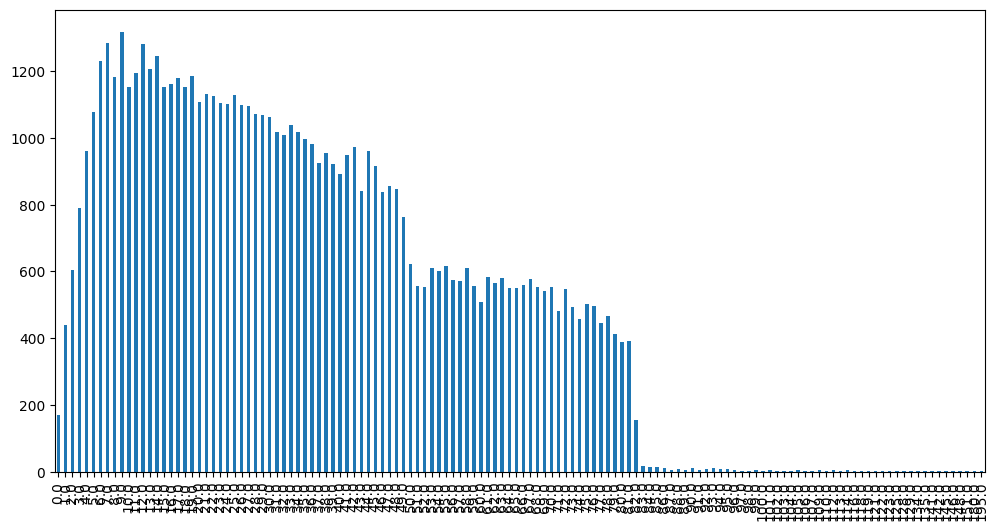

In [28]:
num.num_meses_desde_ult_retraso.value_counts().sort_index().plot.bar(figsize = (12,6));

Hay ceros, pero parecen pocos para una variable que implica retrasos.

Así que vamos a pensar que los nulos significan que no ha habido retrasos.

Y por tanto imputar por ceros.

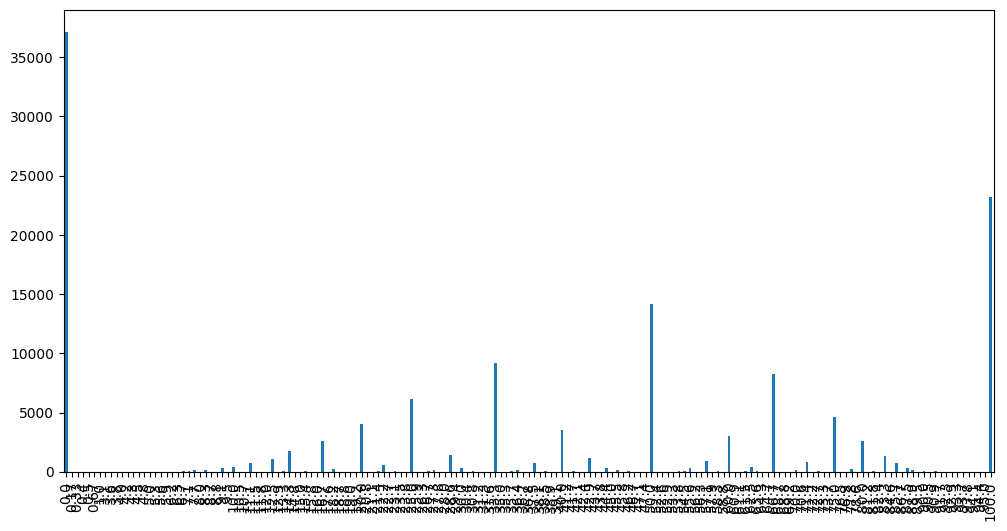

In [29]:
num.porc_tarjetas_75p.value_counts().sort_index().plot.bar(figsize = (12,6));

La categoría mayoritaria es cero.

Imputaremos por cero.

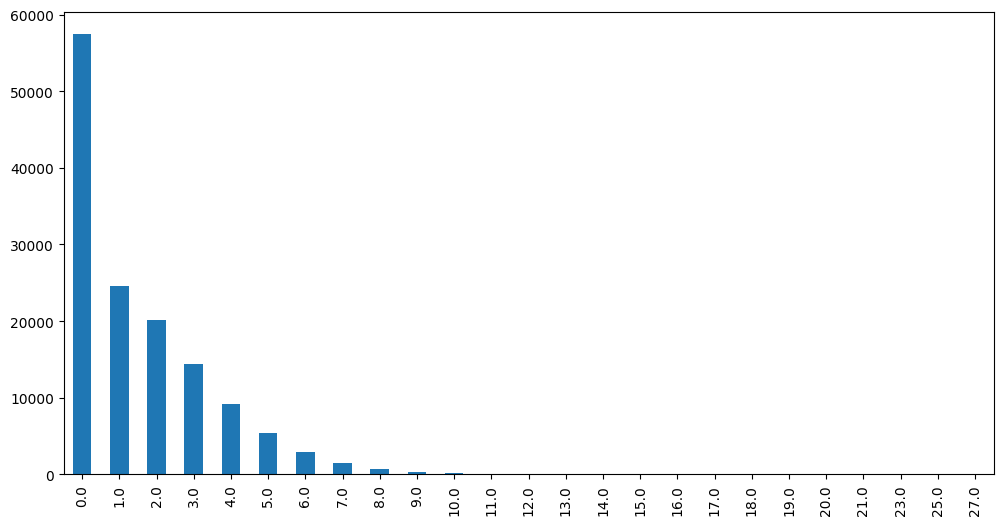

In [30]:
num.num_hipotecas.value_counts().sort_index().plot.bar(figsize = (12,6));

La categoría mayoritaria es cero.

Imputaremos por cero.

Conclusiones:

* imputar todas por ceros

#### Corrección

In [31]:
num.fillna(0,inplace=True)

### Atípicos

#### Por desviación típica

##### Identificación

###### Definir el número de desviaciones típicas

In [32]:
num_desv_tip = 4

###### Función que devuelve los índices de los atípicos

In [33]:
def atipicos_desv_tip(variable, num_desv_tip = 4):
    #sacamos los nulos por ahora
    variable = variable.dropna()
    #calculamos los límites
    media = np.mean(variable)
    sd = np.std(variable)
    umbral = sd * num_desv_tip
    lim_inf = media - umbral
    lim_sup = media + umbral
    #encontramos los índices de los que están fuera de los límites
    indices = [indice for indice,valor in variable.items() if valor < lim_inf or valor > lim_sup]
    return(indices)

###### Función que cuenta el número de atípicos

In [34]:
def conteo_atipicos(df,variable, num_desv_tip = 4):
    atipicos = atipicos_desv_tip(df[variable], num_desv_tip)
    return(df.loc[atipicos,variable].value_counts().sort_index())

###### Variables a aplicar

In [35]:
var_atipicos_dt = ['ingresos','principal','imp_cuota','imp_recuperado']

###### Aplicar

In [36]:
for variable in var_atipicos_dt:
    print('\n' + variable + ':\n')
    print(conteo_atipicos(num,variable,num_desv_tip))


ingresos:

397,000.00       1
398,000.00       1
398,736.00       1
400,000.00      91
402,900.00       1
                ..
7,000,000.00     1
7,845,315.00     1
8,500,000.00     1
8,500,021.00     1
9,550,000.00     1
Name: ingresos, Length: 156, dtype: int64

principal:

Series([], Name: principal, dtype: int64)

imp_cuota:

1,516.27    2
1,535.71    1
1,566.80    2
1,587.02    1
1,607.80    1
1,714.54    1
Name: imp_cuota, dtype: int64

imp_recuperado:

3,200.00     2
3,203.54     1
3,204.00     1
3,204.30     1
3,204.81     1
            ..
26,172.99    1
27,478.64    1
27,657.68    1
33,407.16    1
33,666.34    1
Name: imp_recuperado, Length: 1575, dtype: int64


Revisamos con más detalle la variable ingresos.

In [37]:
num.ingresos.describe()

count     140,000.00
mean       78,056.65
std        79,549.17
min             0.00
25%        46,000.00
50%        65,000.00
75%        93,000.00
max     9,550,000.00
Name: ingresos, dtype: float64

##### Corrección

Eliminar los registros con ingresos superiores a 300.000$

###### Id de registros a eliminar

In [38]:
a_eliminar = num.loc[num.ingresos > 300000].index.values
a_eliminar

array([ 97629676,    601669, 115087816,  30115373,  58654033,  96702950,
        70180828,  83678168,  57316403,  75468055, 104953803,  55380417,
        68355962,  59101444,  74703269,  70631462,  26329813, 101561119,
       114093587,    458760, 145133997,  70701688, 113905376,  91162705,
        69967314, 134144676,  79015002,  33371205, 114793732,  97457564,
       115048244,   9746316, 110905405, 128843574,  75358546, 142502569,
       104959821, 107733336,  93092543,  91131807, 122689487,  57074442,
       133401013,  60831304,  40942257, 116881558, 115085050,  78419419,
        67427919,  92659557,  60963266, 138925364, 102523636, 128067879,
        88921166,  65087421,  18895853, 109743090,    225812, 131383380,
       141468030,  92035926, 137347897,  53252537,  60873988, 144125851,
       107355068, 125518577, 120217704, 104110402,  65795964,  59242936,
       125737574, 132251779, 134479546, 134323203,   2367546,  96979795,
          620850,  40385541, 120150582,  74585468, 

###### Aplicar

In [39]:
cat = cat[~cat.index.isin(a_eliminar)]
num = num[~num.index.isin(a_eliminar)]

## GUARDAR DATASETS TRAS CALIDAD DE DATOS

### Definir los nombres de los archivos

In [40]:
ruta_trabajo = INTERIM_DATA_DIR / 'trabajo_resultado_calidad.pickle'
ruta_cat = INTERIM_DATA_DIR / 'cat_resultado_calidad.pickle'
ruta_num = INTERIM_DATA_DIR / 'num_resultado_calidad.pickle'

### Guardar los archivos

In [41]:
df.to_pickle(ruta_trabajo)
cat.to_pickle(ruta_cat)
num.to_pickle(ruta_num)